# Content Keyword (CKS) Sharing Analysis
Analyzing the geographic spread of individual content keywords.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

img_df = pd.read_csv('../../DATA/02_image_clusters/full_image_data_feb_25.csv')
book_df = pd.read_csv('../../DATA/01_corpus_metadata/full_book_data_feb_25.csv')
geo_df = pd.read_csv('../../DATA/02_image_clusters/full_image_data_feb_25_corrected_centrality_earth.csv')

# Map place names to coordinates
geo_map = geo_df.drop_duplicates(subset=['place'])[['place', 'latitude', 'longitude']]

# Merge to get place, latitude, longitude
img_u = img_df.drop(columns=['latitude', 'longitude'], errors='ignore')
img_u = img_u.merge(book_df[['bid','publishers','printers']], on='bid', how='left')
img_u = img_u.merge(geo_map, on='place', how='left')
print(f'Loaded {len(img_df):,} total images.')

Loaded 27,981 total images.


### Extract CKS Values
We split the comma-separated `cks` strings so we can analyze each keyword individually.

In [2]:
# Create a list of dictionaries to build a new flattened dataframe
cks_data = []

for _, row in img_u.dropna(subset=['cks']).iterrows():
    # Split by comma in case multiple CKs are listed
    cks_list = [ck.strip() for ck in str(row['cks']).split(',') if ck.strip()]
    for ck in cks_list:
        cks_data.append({
            'ck': ck,
            'bid': row['bid'],
            'place': row['place'],
            'latitude': row['latitude'],
            'longitude': row['longitude']
        })

cks_df = pd.DataFrame(cks_data)
# We only care if a CK is in a book, so we drop duplicates at the (ck, bid, place) level
cks_u = cks_df.drop_duplicates(subset=['ck', 'bid', 'place']).copy()

print(f'Total unique CKS values found: {cks_u["ck"].nunique():,}')

Total unique CKS values found: 168


### Geographic Spread per Shared CK
For every CK that was printed in more than one book, what was the maximum geographic distance it traveled?

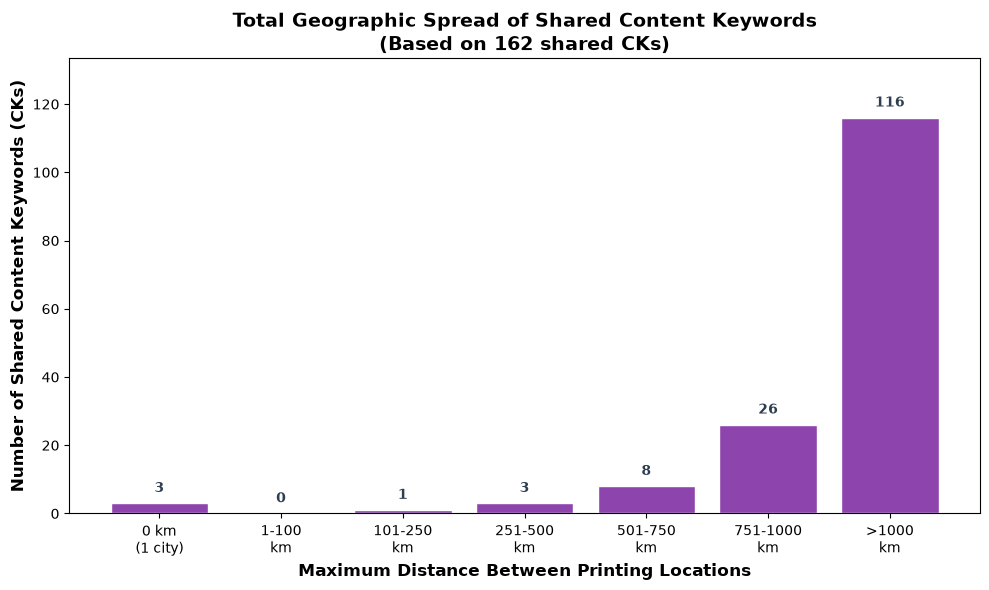

CKs that were shared but never left their origin city: 3 (1.9%)
CKs that spread across Europe (>750 km): 142 (87.7%)


In [3]:
# Filter to shared CKs only
ck_sizes_spread = cks_u.groupby('ck')['bid'].nunique()
shared_cks_spread = ck_sizes_spread[ck_sizes_spread > 1].index
spread_df = cks_u[cks_u['ck'].isin(shared_cks_spread)].copy()
spread_df = spread_df.dropna(subset=['latitude', 'longitude', 'place'])

def haversine(lat1, lon1, lat2, lon2):
    R = 6371 # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Get unique lat/lons per CK to compute pairwise distances
places = spread_df.drop_duplicates(subset=['ck', 'place'])[['ck', 'latitude', 'longitude']].copy()

max_distances = {}
for ck, group in places.groupby('ck'):
    coords = group[['latitude', 'longitude']].values
    if len(coords) < 2:
        max_distances[ck] = 0
        continue
    
    # Calculate all pairwise distances to find the maximum physical spread
    n = len(coords)
    max_d = 0
    for i in range(n):
        for j in range(i+1, n):
            d = haversine(coords[i][0], coords[i][1], coords[j][0], coords[j][1])
            if d > max_d:
                max_d = d
    max_distances[ck] = max_d

d_series = pd.Series(max_distances)

# Bin the maximum distances
bins = [-1, 0, 100, 250, 500, 750, 1000, 5000]
labels = ['0 km\n(1 city)', '1-100\nkm', '101-250\nkm', '251-500\nkm', '501-750\nkm', '751-1000\nkm', '>1000\nkm']
cats = pd.cut(d_series, bins=bins, labels=labels)
counts = cats.value_counts().reindex(labels)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(counts.index, counts.values, color='#8e44ad', edgecolor='white')

# Add exact count on top of every bar
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + counts.values.max()*0.02, f'{yval:,}', 
            ha='center', va='bottom', fontsize=10, color='#2c3e50', fontweight='bold')

ax.set_ylim(0, counts.values.max() * 1.15)
ax.set_xlabel('Maximum Distance Between Printing Locations', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Shared Content Keywords (CKs)', fontsize=12, fontweight='bold')
ax.set_title('Total Geographic Spread of Shared Content Keywords\n'              f'(Based on {len(d_series):,} shared CKs)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
print(f"CKs that were shared but never left their origin city: {counts.iloc[0]:,} ({counts.iloc[0]/len(d_series)*100:.1f}%)")
print(f"CKs that spread across Europe (>750 km): {counts.iloc[5] + counts.iloc[6]:,} ({(counts.iloc[5] + counts.iloc[6])/len(d_series)*100:.1f}%)")


### Inter-City CKS Sharing Network
We visualize how Content Keywords are shared between cities. A directed edge from City A to City B indicates that more than 50% of the shared CKs present in City A are also present in City B.

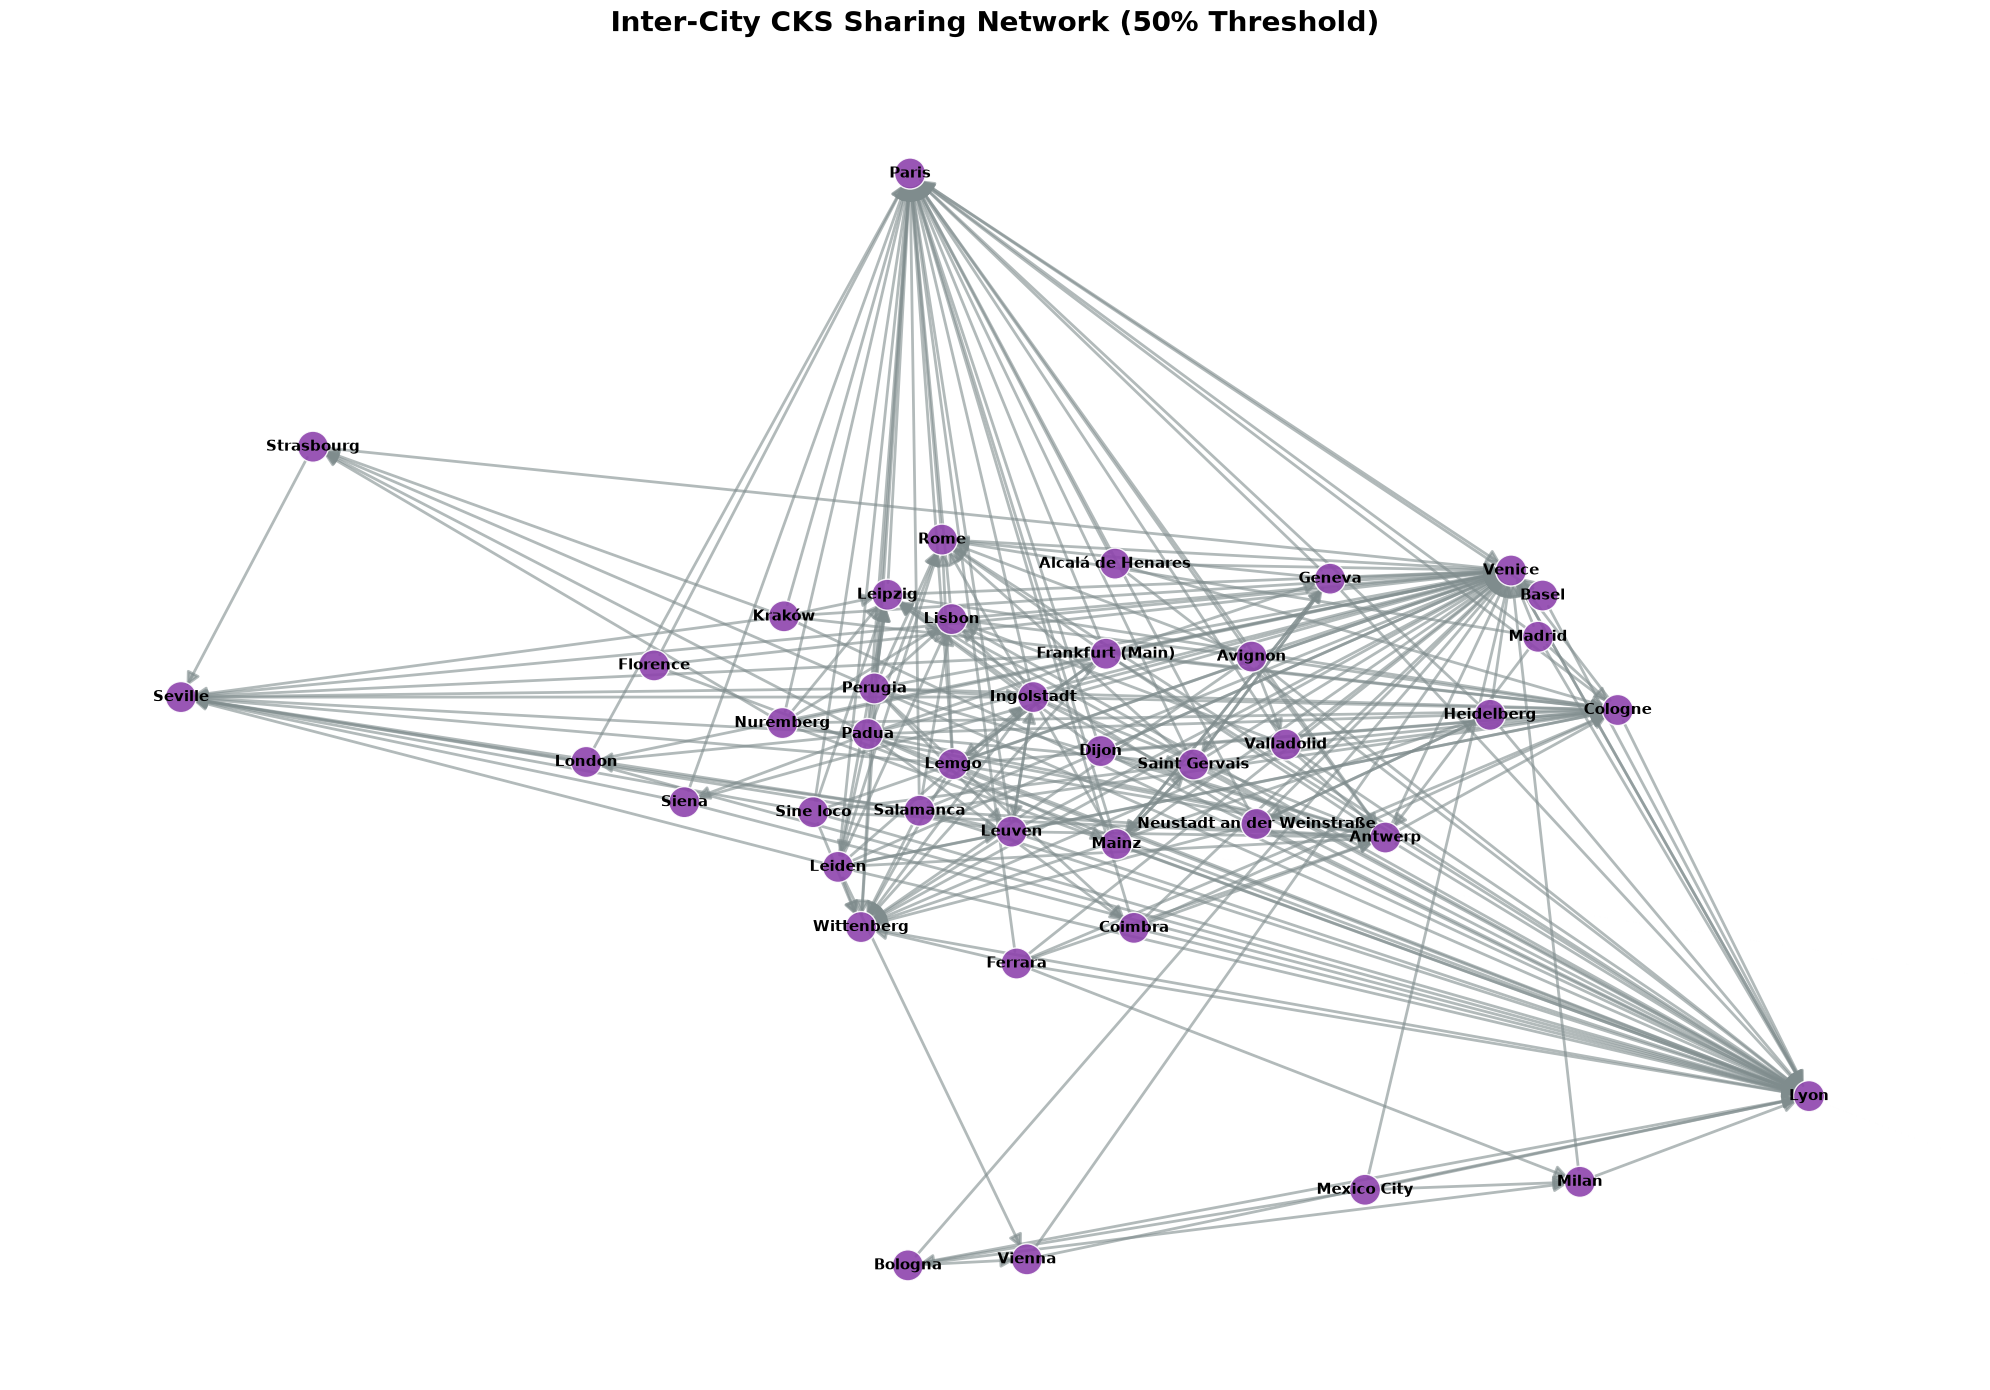

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# Identify inter-city shared CKs
ck_places = cks_u.groupby('ck')['place'].nunique()
inter_city_cks = ck_places[ck_places > 1].index
shared_df_inter = cks_u[cks_u['ck'].isin(inter_city_cks)]
ck_city_pairs = shared_df_inter[['ck', 'place']].drop_duplicates()

# Calculate totals per city and shared counts
city_totals = ck_city_pairs.groupby('place')['ck'].nunique()
pivot = pd.crosstab(ck_city_pairs['ck'], ck_city_pairs['place'])

G = nx.DiGraph()
all_cities = cks_u['place'].dropna().unique()
G.add_nodes_from(all_cities)

cities_with_shares = city_totals.index
for city_a in cities_with_shares:
    if city_totals[city_a] == 0: continue
    for city_b in cities_with_shares:
        if city_a == city_b: continue
        common = pivot[(pivot[city_a] > 0) & (pivot[city_b] > 0)].shape[0]
        if common / city_totals[city_a] > 0.8: # 50% threshold
            G.add_edge(city_a, city_b, weight=common / city_totals[city_a])

# Visualization: High-Readability Static Plot
plt.figure(figsize=(20, 14))
pos = nx.spring_layout(G, k=0.2, iterations=500, seed=42)
node_size = 500
node_colors = ['#8e44ad' if G.degree(node) > 0 else '#ecf0f1' for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors, alpha=0.9, edgecolors='white', linewidths=1)
nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color='#7f8c8d', arrowstyle='-|>', arrowsize=20, width=2, alpha=0.6)

plt.title('Inter-City CKS Sharing Network (50% Threshold)', fontsize=20, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()
